In [92]:
import pandas as pd
import os

all_df = pd.read_excel('./data/HW_Results.xlsx')
df32 = all_df[all_df['Size'] == 32].copy()
df64 = all_df[all_df['Size'] == 64].copy()
df96 = all_df[all_df['Size'] == 96].copy()
df128 = all_df[all_df['Size'] == 128].copy()

df_spatten_energygain = pd.read_excel('./data/data_spatten_over_others_energy.xlsx')
df_spatten_speedup = pd.read_excel('./data/data_spatten_over_others_latency.xlsx')


In [93]:
df96

,Genre,Size,Verilog Name,Module,Cycle Count,Area um2,Area mm2,Power uW,Power mW,Power W,COUNT,Total Area mm2,Total Power W,Latency,Energy
40,Attention Score,96,a1_q_buffer,Q buffer,1.0,37171.200000,0.037200,69882.3,69.8823,0.069900,1.0,0.037200,0.069900,2.000000e-09,1.400000e-10
41,Attention Score,96,NaN,Key SRAM,1.0,NaN,1.051000,NaN,NaN,NaN,1.0,1.051000,NaN,NaN,NaN
42,Attention Score,96,a2_ML_REG,ML_REG,1.0,38342.400000,0.038300,72101.4,72.1014,0.072100,1.0,0.038300,0.072100,2.000000e-09,1.440000e-10
43,BA-CAM,96,NaN,96x96 CAM,1.0,30412.800000,0.030400,158000.0,158.0000,0.158000,1.0,0.030400,0.226800,2.000000e-09,4.540000e-10
44,BA-CAM,96,a3_input_buf,96x1 buf,1.0,1152.000000,0.001200,2174.4,2.1744,0.002200,1.0,0.001200,0.002200,2.000000e-09,4.350000e-12
45,BA-CAM,96,a4_11bit_adc,11bit ADC,1.0,855.300000,0.000900,1783.3,1.7833,0.001800,96.0,0.082100,0.170400,2.000000e-09,3.410000e-10
46,BA-CAM,96,a5_x8,x8,1.0,261.400000,0.000300,774.8,0.7748,0.000800,96.0,0.025100,0.074400,2.000000e-09,1.490000e-10
47,BA-CAM,96,a6_sub96,-CAMH subtractor,1.0,399.900000,0.000400,954.0,0.9540,0.001000,96.0,0.038400,0.091600,2.000000e-09,1.830000e-10
48,BA-CAM,96,a7_accum_array,ACCUM array,14.0,43181.300000,0.043200,67085.3,67.0853,0.067100,1.0,0.043200,0.067100,2.000000e-09,1.340000e-10
49,BA-CAM,96,a8_top3,Top3,87.0,7154.000000,0.007200,3841.5,3.8415,0.003800,1.0,0.007200,0.003800,2.000000e-09,7.680000e-12


In [ ]:
import math
def get_appropriate_df(size):
    if size == 32:
        return df32
    elif size == 64:
        return df64
    elif size == 96:
        return df96
    elif size == 128:
        return df128
    else:
        raise ValueError(f"Unsupported size: {size}")

def get_module_name(base_module, size):
    # Dictionary mapping base module names to their size-specific variants
    module_mappings = {
        "CAM": {
            32: "ML_REG",
            64: "ML_REG",
            96: "ML_REG",
            128: "ML_REG"
        },
        "buf": {
            32: "32x1 buf",
            64: "64x1 buf",
            96: "96x1 buf",
            128: "128x1 buf"
        },
        "ADC": {
            32: "9bit ADC",
            64: "10bit ADC",
            96: "11bit ADC",
            128: "11bit ADC"
        },
        "x8": {
            32: "x8",
            64: "x8",
            96: "x8",
            128: "x8"
        },
        "-CAMH subtractor": {
            32: "-CAMH subtractor",
            64: "-CAMH subtractor",
            96: "-CAMH subtractor",
            128: "-CAMH subtractor"
        },
        "ACCUM array": {
            32: "ACCUM array",
            64: "ACCUM array",
            96: "ACCUM array",
            128: "ACCUM array"
        },
        "Top3": {
            32: "Top3",
            64: "Top3",
            96: "Top3",
            128: "Top3"
        },
        "Convert": {
            32: "Convert",
            64: "Convert",
            96: "Convert",
            128: "Convert"
        },
        "Top30": {
            32: "Top30",
            64: "Top30",
            96: "Top30",
            128: "Top30"
        },
        "SoftMax": {
            32: "SoftMax",
            64: "SoftMax",
            96: "SoftMax",
            128: "SoftMax"
        },
        "Sparse MatMul": {
            32: "Sparse MatMul",
            64: "Sparse MatMul",
            96: "Sparse MatMul",
            128: "Sparse MatMul"
        }
    }

    return module_mappings[base_module][size]

def cycle_scaler(base_module, size, scale):
    df = get_appropriate_df(size)
    module_name = get_module_name(base_module, size)
    mask = df["Module"] == module_name
    df.loc[mask, "Active Cycles"] = df.loc[mask, "Cycle Count"] * scale
    return df.loc[mask, "Active Cycles"].item()

def cycle_summer(modules, size):
    total_cycles = 0
    df = get_appropriate_df(size)
    for module in modules:
        module_name = get_module_name(module, size)
        mask = df["Module"] == module_name
        cycles = df.loc[mask, "Active Cycles"].item()
        total_cycles += cycles
    return total_cycles

def energy_summer(modules, size):
    df = get_appropriate_df(size)
    total_energy = 0
    for module in modules:
        module_name = get_module_name(module, size)
        mask = df["Module"] == module_name
        df.loc[mask, "Active Energy"] = df.loc[mask, "Total Power W"] * df.loc[mask, "Active Cycles"] * 2e-9
        total_energy += df.loc[mask, "Active Energy"].item()
    return total_energy

def total_cycle_energy(k, n, CAMH, CAMW):

    size = CAMH  # Using CAMH as the size since CAMH == CAMW
    tiling_count = math.ceil(k/CAMW) * math.ceil(n/CAMH)

    #TODO add SRAMs

    # TILE components
    TILE_CMP = ["CAM", "buf", "ADC", "x8", "-CAMH subtractor", "ACCUM array"]
    for module in TILE_CMP:
        cycle_scaler(module, size, tiling_count)

    
    # CAMH components
    CAMH_CMP = ["Top3", "Convert"]
    for module in CAMH_CMP:
        cycle_scaler(module, size, math.ceil(1024/CAMH))

    att = cycle_summer(TILE_CMP, size) + cycle_summer(CAMH_CMP, size)
    att_en = energy_summer(TILE_CMP, size) + energy_summer(CAMH_CMP, size)



    # topk softmax 
    for module in ["Top30", "SoftMax"]:
        cycle_scaler(module, size, 1)
    tk_sm =  cycle_summer(["Top30", "SoftMax"], size) 
    tk_sm_en = energy_summer(["Top30", "SoftMax"], size)

    # sparse matmul
    for module in ["Sparse MatMul"]:
        cycle_scaler(module, size, 1)
    spmatmul =  cycle_summer(["Sparse MatMul"], size) + 3 # What is this 3 for?
    spmatmul_en = energy_summer(["Sparse MatMul"], size)

    # Adjust cycles for output register based on sparse matmul

    print("Attention cycles:", att)
    print("Attention energy:", att_en)
    print("Top-k softmax cycles:", tk_sm)
    print("Top-k softmax energy:", tk_sm_en)
    print("Sparse matmul cycles:", spmatmul)
    print("Sparse matmul energy:", spmatmul_en)

    return att + tk_sm + spmatmul, att_en + tk_sm_en + spmatmul_en

cycle, energy = total_cycle_energy(k=1024, n=1024, CAMH=96, CAMW=96)
print(f"Total cycle count: {cycle}")
print(f"Total energy: {energy}")


Attention cycles: 3267.0
Attention energy: 3.3402600000000003e-07
Top-k softmax cycles: 126.0
Top-k softmax energy: 2.7829278e-09
Sparse matmul cycles: 1027.0
Sparse matmul energy: 6.41024e-06
Total cycle count: 4420.0
Total energy: 6.747048927800001e-06


In [95]:

# Modifies the cycles in place
latencies_energies = [total_cycle_energy(k=1024, n=1024, CAMH=size, CAMW=size) for size in [32, 64, 96, 128]]
summary_df = pd.DataFrame({
    'size': [32, 64, 96, 128],
    'area': [
        df32["Total Area mm2"].sum(),
        df64["Total Area mm2"].sum(),
        df96["Total Area mm2"].sum(),
        df128["Total Area mm2"].sum()
    ],
    'energy': [energy for _, energy in latencies_energies],
    'latency': [latency * 2e-9 for latency, _ in latencies_energies]
})

summary_df['power'] = summary_df['energy'] / summary_df['latency']

summary_df

Attention cycles: 16896.0
Attention energy: 5.044675008e-07
Top-k softmax cycles: 126.0
Top-k softmax energy: 2.7829278e-09
Sparse matmul cycles: 1027.0
Sparse matmul energy: 6.41024e-06
Attention cycles: 5440.0
Attention energy: 3.813888e-07
Top-k softmax cycles: 126.0
Top-k softmax energy: 2.7829278e-09
Sparse matmul cycles: 1027.0
Sparse matmul energy: 6.41024e-06
Attention cycles: 3267.0
Attention energy: 3.3402600000000003e-07
Top-k softmax cycles: 126.0
Top-k softmax energy: 2.7829278e-09
Sparse matmul cycles: 1027.0
Sparse matmul energy: 6.41024e-06
Attention cycles: 2208.0
Attention energy: 2.624368e-07
Top-k softmax cycles: 126.0
Top-k softmax energy: 2.7829278e-09
Sparse matmul cycles: 1027.0
Sparse matmul energy: 6.41024e-06


,size,area,energy,latency,power
0,32,6.726110,0.000007,0.000036,0.191631
1,64,6.831875,0.000007,0.000013,0.515275
2,96,6.972375,0.000007,0.000009,0.763241
3,128,7.087375,0.000007,0.000007,0.993076


In [96]:
SpAtten_power = 8.30
SpAtten_area = 18.71
# Where are these from?

In [97]:
sizing_choice = 32
max_num_cores = int(SpAtten_area/area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item())
print(max_num_cores)

sizing_choice = 64
max_num_cores = int(SpAtten_area/area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item())
print(max_num_cores)

sizing_choice = 96
max_num_cores = int(SpAtten_area/area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item())
print(max_num_cores)

sizing_choice = 128
max_num_cores = int(SpAtten_area/area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item())
print(max_num_cores)

2
2
2
2


In [98]:
df_model_dims = pd.read_excel('./data/2_model max dimensions.xlsx')
df_model_dims["multiple"] = df_model_dims["m"] * df_model_dims["layer"]

# sizing_choice = 96
# core = 7

# df_model_dims["latency via CAMformer"] = df_model_dims["multiple"] *  area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["latency"].item() / core
# df_model_dims["area via CAMformer"] = area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item() * core
# df_model_dims["power via CAMformer"] = area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["power"].item()
# df_model_dims["energy via CAMformer"] = df_model_dims["power via CAMformer"] * df_model_dims["latency via CAMformer"]
# df_model_dims

def df_finder(sizing_choice, core_num):
   # Base metrics
   df_model_dims["latency via CAMformer"] = df_model_dims["multiple"] * area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["latency"].item() / core_num
   # Hmm, lets assume perfect parallelism (/ core_num) is ok since we can parallelize over the model dim m (not layer)
   df_model_dims["area via CAMformer"] = area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item() * core_num
   df_model_dims["power via CAMformer"] = area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["power"].item() * core_num
   df_model_dims["energy via CAMformer"] = df_model_dims["power via CAMformer"] * df_model_dims["latency via CAMformer"] + (0.00704643 * core_num) # DRAM read

   # Calculate GOP based on the formula: GOPs = [(m × k × n) + (m × n × dv)] × layers / 1e9
   df_model_dims["GOP"] = ((df_model_dims["m"] * df_model_dims["k"] * df_model_dims["n"]* df_model_dims["n"]) +
                          (df_model_dims["m"] * df_model_dims["n"] * df_model_dims["n"]* df_model_dims["dv"])) * df_model_dims["layer"] / 1e9

   # Calculate GOP based on the formula: GOPs = [(m × k × n) + (m × n × dv)] × layers / 1e9
   df_model_dims["Eff. GOP"] = ((df_model_dims["m"] * df_model_dims["k"] * df_model_dims["n"]* df_model_dims["n"]) +
                          (df_model_dims["m"] * df_model_dims["n"] * 30 * df_model_dims["dv"])) * df_model_dims["layer"] / 1e9
   
   # Where is the 30 coming from? top-k softmax, where 30 is the top-k value
   # Naming is backwards, should be Eff. GOP and GOP, where effective means virtual 
   # but we will keep it for now so later cells work as intended

   # Efficiency metrics
   df_model_dims["Throughput (GOP/s)"] = df_model_dims["GOP"] / df_model_dims["latency via CAMformer"]
   df_model_dims["Energy Efficiency (GOP/J)"] = df_model_dims["GOP"] / df_model_dims["energy via CAMformer"]
   df_model_dims["Energy Eff (GOP/W)"] = df_model_dims["Throughput (GOP/s)"] / df_model_dims["power via CAMformer"]
   df_model_dims["Area Efficiency (GOP/s/mm2)"] = df_model_dims["Throughput (GOP/s)"] / df_model_dims["area via CAMformer"]

   return df_model_dims

temp_df = df_finder(sizing_choice = 32, core_num = 1)
temp_df
# temp_df[temp_df['model'].str.contains("bert-large", case=False)]


,model,layer,m,n,k,dv,multiple,latency via CAMformer,area via CAMformer,power via CAMformer,energy via CAMformer,GOP,Eff. GOP,Throughput (GOP/s),Energy Efficiency (GOP/J),Energy Eff (GOP/W),Area Efficiency (GOP/s/mm2)
0,bert-base-squad-v2,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
1,bert-large-squad-v2,24,512,512,1024,1024,12288,0.443572,6.72611,3.304453,1.472810,6597.069767,3491.808412,14872.594382,4479.240079,4500.773327,2211.173231
2,bert-base-cola,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
3,bert-base-mnli-mm,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
4,bert-base-mnli-m,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
5,bert-base-mrpc,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
6,bert-base-qnli,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
7,bert-base-qqp,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
8,bert-base-rte,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
9,bert-base-sst2,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923


In [99]:
# Need new data from GPU profiling
df_A100 = pd.read_excel('./data/3_profiling_A100.xlsx')
df_L40 = pd.read_excel('./data/3_profiling_L40.xlsx')
df_titanxp = pd.read_excel('./data/3_profiling_titanxp.xlsx')


def calculate_efficiency_metrics(df_gpu, df_model_dims):
   """
   Calculate throughput and energy efficiency using model dimensions
   Sets GOPs to 0 if model not found in df_model_dims
   """
   # Make copy to avoid modifying original dataframe
   df = df_gpu.copy()

   # Convert latency to seconds
   df['latency(s)'] = df['latency(ms)'] / 1000

   # Calculate metrics for each model
   for index, row in df.iterrows():
       model_name = row['model']

       # Find corresponding model in df_model_dims
       matching_models = df_model_dims[df_model_dims['model'] == model_name]

       if len(matching_models) == 0:
           # If model not found, use 0 for GOPs
           gops = 0
           eff_gops = 0
       else:
           model_dims = matching_models.iloc[0]
           # Calculate GOPs
           gops = ((model_dims['m'] * model_dims['k'] * model_dims['n'] * model_dims['n']) +
                   (model_dims['m'] * model_dims['n'] * model_dims['n'] * model_dims['dv'] )) * model_dims['layer'] / 1e9

           eff_gops = ((model_dims['m'] * model_dims['k'] * model_dims['n'] * model_dims['n']) +
                   (model_dims['m'] * model_dims['n'] * 30 * model_dims['dv'] )) * model_dims['layer'] / 1e9
           
           # Again, naming is backwards, but we will keep it for now so later cells work as intended



       # Calculate metrics
       df.loc[index, 'GOPs'] = gops
       df.loc[index, 'Eff. GOPs'] = eff_gops
       df.loc[index, 'Throughput (GOP/s)'] = gops / df.loc[index, 'latency(s)'] if gops != 0 else 0
       df.loc[index, 'Energy Efficiency (GOP/J)'] = gops / df.loc[index, 'energy(Joules)'] if gops != 0 else 0

   return df

# Process each GPU dataset
df_A100_metrics = calculate_efficiency_metrics(df_A100, df_model_dims)
df_L40_metrics = calculate_efficiency_metrics(df_L40, df_model_dims)
df_titanxp_metrics = calculate_efficiency_metrics(df_titanxp, df_model_dims)
df_titanxp_metrics

,model,latency(ms),dynamic power(Watts),energy(Joules),latency(s),GOPs,Eff. GOPs,Throughput (GOP/s),Energy Efficiency (GOP/J)
0,google/vit-base-patch16-224,4.226558,194.949875,0.823967,0.004227,140.919515,81.189670,3.334144e+04,171.025678
1,bert-base-cola,14.287604,185.384500,2.648700,0.014288,2473.901162,1309.428154,1.731502e+05,934.005800
2,gpt2-small-1bw,12.681725,181.739200,2.304767,0.012682,19791.209300,10185.514942,1.560609e+06,8587.075960
3,gpt2-small-ptb,12.715310,181.573525,2.308764,0.012715,19791.209300,10185.514942,1.556487e+06,8572.209762
4,gpt2-small-wikitext103,12.719091,181.524625,2.308828,0.012719,19791.209300,10185.514942,1.556024e+06,8571.972143
5,gpt2-small-wikitext2,13.028105,237.909825,3.099514,0.013028,19791.209300,10185.514942,1.519117e+06,6385.262109
6,gpt2-medium-1bw,44.575253,177.472750,7.910893,0.044575,52776.558133,27161.373180,1.183988e+06,6671.378077
7,gpt2-medium-ptb,44.665835,176.477875,7.882532,0.044666,52776.558133,27161.373180,1.181587e+06,6695.381399
8,gpt2-medium-wikitext103,44.660392,176.655675,7.889512,0.044660,52776.558133,27161.373180,1.181731e+06,6689.457869
9,gpt2-medium-wikitext2,44.667361,176.465750,7.882259,0.044667,52776.558133,27161.373180,1.181546e+06,6695.613292


# Cores study

In [100]:
results = []
sizing_choices = [32, 64, 96, 128]  # adjust based on your actual choices
core_nums = [1, 2, 3, 4, 5, 6, 7]         # adjust based on your actual choices

for sizing_choice in sizing_choices:
    for core_num in core_nums:
        df = df_finder(sizing_choice=sizing_choice, core_num=core_num)

        # Look at each model's performance
        for idx, row in df.iterrows():
            model_name = row['model']
            throughput = row["Throughput (GOP/s)"]
            energy_eff = row["Energy Efficiency (GOP/J)"]
            area = row["area via CAMformer"]
            power = row["power via CAMformer"]
            area_eff = throughput / area  # GOP/s/mm²

            results.append({
                'Model': model_name,
                'Sizing': sizing_choice,
                'Cores': core_num,
                'Throughput': throughput,
                'Energy_Efficiency': energy_eff,
                'Area': area,
                'Power': power,
                'Area_Efficiency': area_eff
            })

result_df = pd.DataFrame(results)

# Find models that perform well compared to baselines
promising_models = result_df[
    (result_df['Throughput'] > 360) &        # Better than MNNFast
    (result_df['Energy_Efficiency'] > 382) &  # Better than MNNFast
    (result_df['Area'] < 18.71)      # Better than A³
]

# No restriction on pd dataframe size 
pd.set_option('display.max_rows', None)


print("Models with good performance across all metrics:")
promising_models.sort_values(['Throughput', 'Energy_Efficiency', 'Area_Efficiency'],
                                 ascending=False)#[['Model', 'Sizing', 'Cores',
                                                 #'Throughput', 'Energy_Efficiency',
                                                 #'Area']]


Models with good performance across all metrics:


,Model,Sizing,Cores,Throughput,Energy_Efficiency,Area,Power,Area_Efficiency
454,gpt2-medium-1bw,128,2,638941.876822,72572.308323,14.174750,8.633595,45076.060941
455,gpt2-medium-ptb,128,2,638941.876822,72572.308323,14.174750,8.633595,45076.060941
456,gpt2-medium-wikitext103,128,2,638941.876822,72572.308323,14.174750,8.633595,45076.060941
457,gpt2-medium-wikitext2,128,2,638941.876822,72572.308323,14.174750,8.633595,45076.060941
314,gpt2-medium-1bw,96,2,485856.028959,60410.828369,13.944750,7.912795,34841.502564
315,gpt2-medium-ptb,96,2,485856.028959,60410.828369,13.944750,7.912795,34841.502564
316,gpt2-medium-wikitext103,96,2,485856.028959,60410.828369,13.944750,7.912795,34841.502564
317,gpt2-medium-wikitext2,96,2,485856.028959,60410.828369,13.944750,7.912795,34841.502564
450,gpt2-small-1bw,128,2,479206.407617,53394.504739,14.174750,8.633595,33807.045706
451,gpt2-small-ptb,128,2,479206.407617,53394.504739,14.174750,8.633595,33807.045706


# CAMformer vs GPUs

In [101]:
# First, get all model names from each dataframe
models_camformer = set(df_finder(sizing_choice = 96, core_num = 2)['model'].tolist())
models_a100 = set(df_A100_metrics['model'].tolist())
models_l40 = set(df_L40_metrics['model'].tolist())
models_titanxp = set(df_titanxp_metrics['model'].tolist())

# Find common models across all four dataframes
common_models = models_camformer.intersection(models_a100, models_l40, models_titanxp)




listter = ['gpt2-medium-wikitext103', 'gpt2-small-wikitext103', 'bert-large-squad-v2', 'gpt2-medium-wikitext2', 'bert-base-mnli-mm', 'bert-base-qqp', 'gpt2-medium-1bw', 'gpt2-medium-ptb', 'bert-base-qnli', 'gpt2-small-1bw', 'bert-base-squad-v2', 'google/vit-base-patch16-224', 'gpt2-small-ptb', 'gpt2-small-wikitext2', 'bert-base-sst2', 'bert-base-cola', 'bert-base-mnli-m', 'bert-base-rte', 'bert-base-mrpc']
for i in range(len(listter)):
  print(listter[i])

gpt2-medium-wikitext103
gpt2-small-wikitext103
bert-large-squad-v2
gpt2-medium-wikitext2
bert-base-mnli-mm
bert-base-qqp
gpt2-medium-1bw
gpt2-medium-ptb
bert-base-qnli
gpt2-small-1bw
bert-base-squad-v2
google/vit-base-patch16-224
gpt2-small-ptb
gpt2-small-wikitext2
bert-base-sst2
bert-base-cola
bert-base-mnli-m
bert-base-rte
bert-base-mrpc


In [102]:


# # Let's create a plotting function for selected models
# def plot_performance_metrics(models_to_plot, df_cam, df_a100, df_l40, df_titanxp):
#    """
#    Create two plots: Throughput vs Latency and Energy Efficiency vs Latency
#    for selected models across different platforms
#    """
#    import matplotlib.pyplot as plt

#    # Create figure with two subplots
#    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#    # Colors and markers for different platforms
#    platforms = {
#        'CAMformer': {'color': 'blue', 'marker': 'o'},
#        'A100': {'color': 'red', 'marker': 's'},
#        'L40': {'color': 'green', 'marker': '^'},
#        'TitanXP': {'color': 'purple', 'marker': 'D'}
#    }

#    # Plot for each model
#    for model in models_to_plot:
#        # Get data points for each platform
#        cam_data = df_cam[df_cam['model'] == model]
#        #print(cam_data)
#        a100_data = df_a100[df_a100['model'] == model]
#        l40_data = df_l40[df_l40['model'] == model]
#        titan_data = df_titanxp[df_titanxp['model'] == model]

#        # Throughput vs Latency
#        ax1.scatter(cam_data['latency via CAMformer'], cam_data['Throughput (GOP/s)'],
#                   label=f'{model}-CAMformer', **platforms['CAMformer'])
#        ax1.scatter(a100_data['latency(s)'], a100_data['Throughput (GOP/s)'],
#                   label=f'{model}-A100', **platforms['A100'])
#        ax1.scatter(l40_data['latency(s)'], l40_data['Throughput (GOP/s)'],
#                   label=f'{model}-L40', **platforms['L40'])
#        ax1.scatter(titan_data['latency(s)'], titan_data['Throughput (GOP/s)'],
#                   label=f'{model}-TitanXP', **platforms['TitanXP'])

#        # Energy Efficiency vs Latency
#        ax2.scatter(cam_data['latency via CAMformer'], cam_data['Energy Efficiency (GOP/J)'],
#                   label=f'{model}-CAMformer', **platforms['CAMformer'])
#        ax2.scatter(a100_data['latency(s)'], a100_data['Energy Efficiency (GOP/J)'],
#                   label=f'{model}-A100', **platforms['A100'])
#        ax2.scatter(l40_data['latency(s)'], l40_data['Energy Efficiency (GOP/J)'],
#                   label=f'{model}-L40', **platforms['L40'])
#        ax2.scatter(titan_data['latency(s)'], titan_data['Energy Efficiency (GOP/J)'],
#                   label=f'{model}-TitanXP', **platforms['TitanXP'])

#    # Configure first plot
#    ax1.set_xlabel('Latency (s)')
#    ax1.set_ylabel('Throughput (GOP/s)')
#    ax1.set_title('Throughput vs Latency')
#    ax1.grid(True)
#    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

#    # Configure second plot
#    ax2.set_xlabel('Latency (s)')
#    ax2.set_ylabel('Energy Efficiency (GOP/J)')
#    ax2.set_title('Energy Efficiency vs Latency')
#    ax2.grid(True)
#    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

#    plt.tight_layout()
#    plt.show()

# # Example usage - replace with your chosen models
# selected_models = ['bert-base-rte']


# # gpt2-medium-wikitext103
# # gpt2-small-wikitext103
# # bert-large-squad-v2
# # gpt2-medium-wikitext2
# # bert-base-mnli-mm
# # bert-base-qqp
# # gpt2-medium-1bw
# # gpt2-medium-ptb
# # bert-base-qnli
# # gpt2-small-1bw
# # bert-base-squad-v2
# # google/vit-base-patch16-224
# # gpt2-small-ptb
# # gpt2-small-wikitext2
# # bert-base-sst2
# # bert-base-cola
# # bert-base-mnli-m
# # bert-base-rte
# # bert-base-mrpc

# # selected_models = listter  # Replace with models you want to plot
# for selected_model in  listter:
#   print(selected_model)
#   modelist = [selected_model]
#   plot_performance_metrics(modelist, df_finder(sizing_choice = 96, core_num = 1), df_A100_metrics, df_L40_metrics, df_titanxp_metrics)

# Pie chart

In [103]:
import matplotlib.pyplot as plt
import numpy as np

input_df = df96
input_df = input_df.fillna(0)
area_values = input_df['Area mm2.1'].tolist() # in mm2
power_values = input_df['Power W.1'].tolist() # in W
labels = input_df['Module'].tolist()
# Calculate percentages correctly
area_percentages = (input_df['Area mm2.1'] / input_df['Area mm2.1'].sum()).tolist() # No need for tolist() here
power_percentages = (input_df['Power W.1'] / input_df['Power W.1'].sum()).tolist() # No need for tolist() here
def process_module_data(input_df, threshold=4, area_col='Area mm2.1', power_col='Power W.1', module_col='Module'):
    """
    Process module data to combine values below threshold into 'Others' category, separately for area and power

    Args:
        input_df (pd.DataFrame): Input DataFrame containing module data
        threshold (float): Threshold percentage (0-100) below which values are combined into 'Others'
        area_col (str): Name of the area column
        power_col (str): Name of the power column
        module_col (str): Name of the module label column

    Returns:
        tuple: (area_values, power_values, labels_area, labels_power, area_percentages, power_percentages)
    """
    # Fill NaN values with 0
    input_df = input_df.fillna(0)

    # Initialize new lists for area
    new_labels_area = []
    new_area_values = []

    # Initialize new lists for power
    new_labels_power = []
    new_power_values = []

    # Calculate initial percentages
    area_percentages = input_df[area_col] / input_df[area_col].sum() * 100
    power_percentages = input_df[power_col] / input_df[power_col].sum() * 100

    # Process area values
    others_area = 0
    for index, row in input_df.iterrows():
        if area_percentages[index] >= threshold:
            new_labels_area.append(row[module_col])
            new_area_values.append(row[area_col])
        else:
            others_area += row[area_col]

    # Add Others category for area if needed
    if others_area > 0:
        new_labels_area.append("Others")
        new_area_values.append(others_area)

    # Process power values
    others_power = 0
    for index, row in input_df.iterrows():
        if power_percentages[index] >= threshold:
            new_labels_power.append(row[module_col])
            new_power_values.append(row[power_col])
        else:
            others_power += row[power_col]

    # Add Others category for power if needed
    if others_power > 0:
        new_labels_power.append("Others")
        new_power_values.append(others_power)

    # Calculate final percentages
    new_area_percentages = [value/sum(new_area_values)*100 for value in new_area_values]
    new_power_percentages = [value/sum(new_power_values)*100 for value in new_power_values]

    return new_area_values, new_power_values, new_labels_area, new_labels_power, new_area_percentages, new_power_percentages

# Example usage:
area_values, power_values, labels_area, labels_power, area_percentages, power_percentages = process_module_data(df96)

# Create separate legend labels for area and power
legend_labels_area = [f'{labels_area[i]}\n{area_percentages[i]:.2f}%' for i in range(len(labels_area))]
legend_labels_power = [f'{labels_power[i]}\n{power_percentages[i]:.2f}%' for i in range(len(labels_power))]


print(labels)
# Print results to verify
print("\nArea Labels:", labels_area)
print("Area Percentages:", [f"{x:.2f}%" for x in area_percentages])
print("\nPower Labels:", labels_power)
print("Power Percentages:", [f"{x:.2f}%" for x in power_percentages])

print(area_values)
print(power_values)
print(labels_area)
print(area_percentages)
print(power_percentages)

# Area Plot
fig1, ax1 = plt.subplots(figsize=(3*0.9, 2*0.9), dpi=600)
wedges1, texts1, autotexts1 = ax1.pie(area_values,
                                     colors=['#2b8cbe', '#43a2ca', '#a8ddb5', '#f4a582', '#92c5de'],
                                     autopct='',
                                     startangle=90,
                                     radius=1.3)

# Add title
# ax1.set_title('(a) Area', pad=20, fontsize=7)

# Add value labels inside the pie slices
for i, wedge in enumerate(wedges1):
    x, y = wedge.center
    angle = np.pi/180 * (wedge.theta1 + wedge.theta2) / 2
    x = x + 1 * np.cos(angle)
    y = y + 1 * np.sin(angle)
    ax1.text(x, y, f'{area_values[i]:.3f}', ha='center', va='center', color='white', fontsize=7)



# Create legend with vertical stacking
legend_labels = [f'{labels[i]}\n{area_percentages[i]:.2f}%' for i in range(len(labels_area))]
ax1.legend(wedges1, legend_labels_area,
          loc='center left',
          bbox_to_anchor=(1.1, 0.5),
          frameon=False,
          fontsize=5,
          ncol=1)  # This ensures vertical stacking

plt.tight_layout()
plt.show()




# Power Plot
fig2, ax2 = plt.subplots(figsize=(3*0.9, 2*0.9), dpi=600)
wedges2, texts2, autotexts2 = ax2.pie(power_values,
                                     colors=['#2b8cbe', '#43a2ca', '#a8ddb5', '#f4a582', '#92c5de'],
                                     autopct='',
                                     startangle=90,
                                     radius=1.3)

# Add title
# ax2.set_title('(b) Power', pad=20, fontsize=7)

# Add value labels inside the pie slices
for i, wedge in enumerate(wedges2):
    x, y = wedge.center
    angle = np.pi/180 * (wedge.theta1 + wedge.theta2) / 2
    x = x + 1 * np.cos(angle)
    y = y + 1 * np.sin(angle)
    ax2.text(x, y, f'{power_values[i]:.2f}', ha='center', va='center', color='white', fontsize=7)

# Create legend with vertical stacking
legend_labels = [f'{labels[i]}\n{power_percentages[i]:.2f}%' for i in range(len(labels_power))]
ax2.legend(wedges2, legend_labels_power,
          loc='center left',
          bbox_to_anchor=(1.1, 0.5),
          frameon=False,
          fontsize=5,
          ncol=1)  # This ensures vertical stacking

plt.tight_layout()
plt.show()

KeyError: 'Area mm2.1'

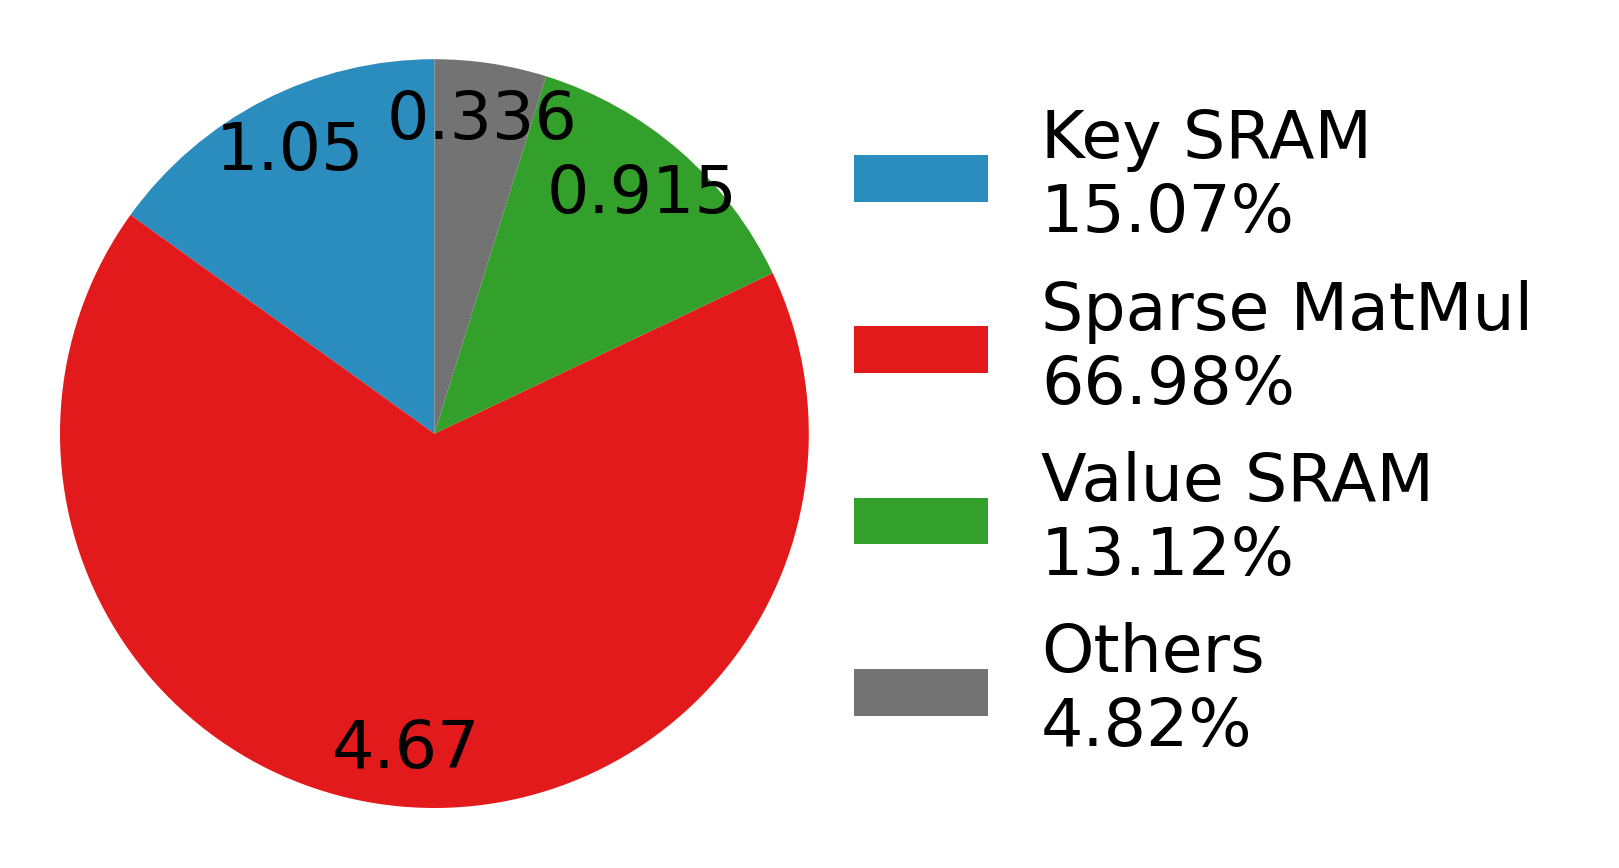

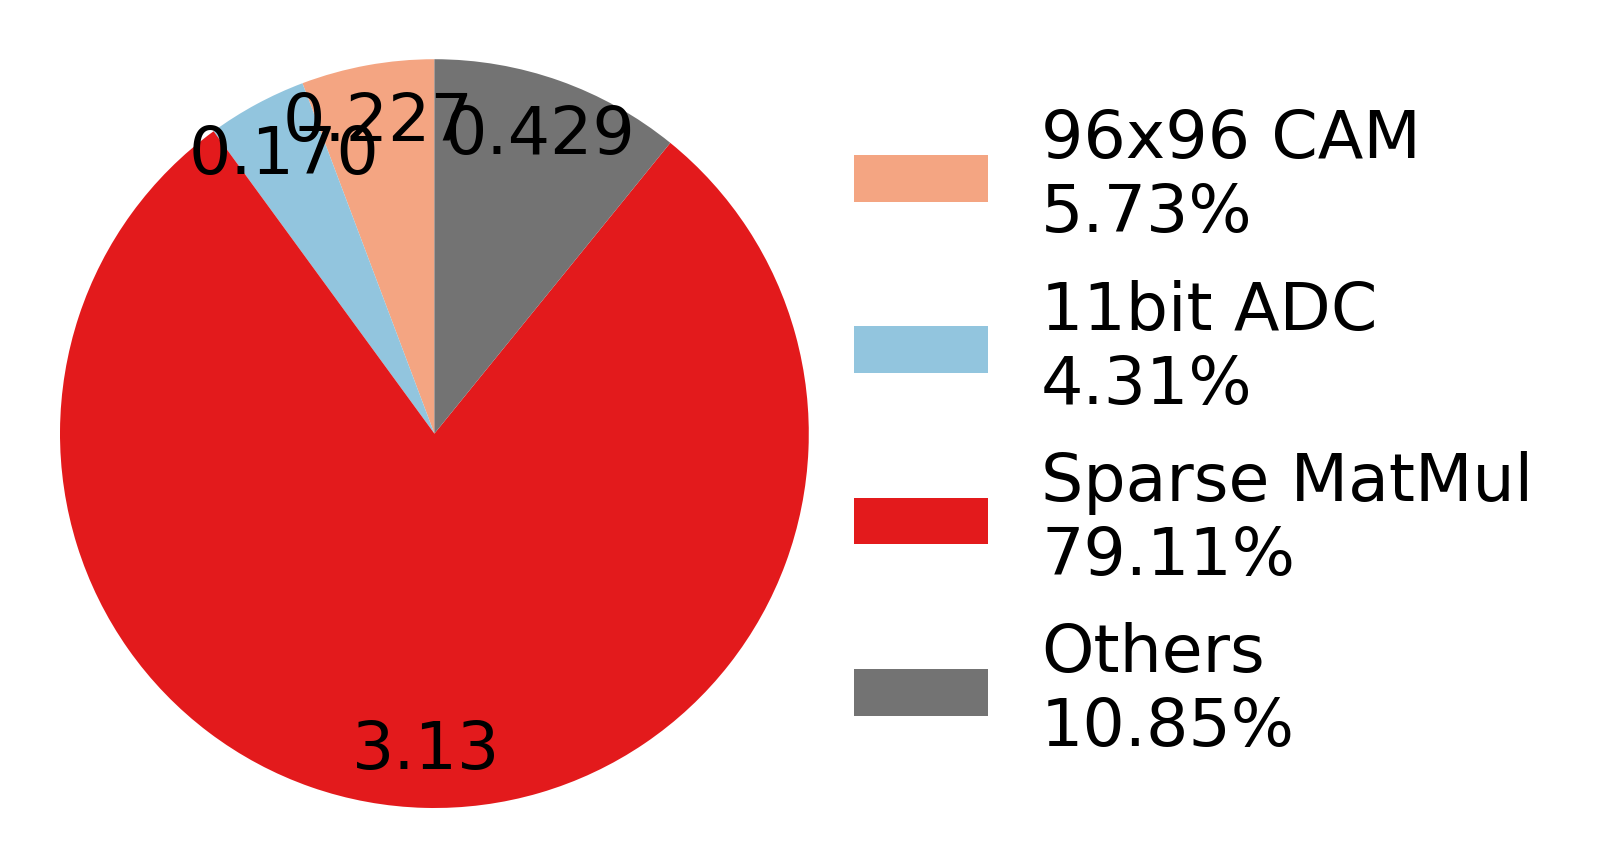

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Color mapping dictionary
color_mapping = {
    'Key SRAM': '#2b8cbe',
    'Sparse MatMul': '#e31a1c',
    'Value SRAM': '#33a02c',
    '96x96 CAM': '#f4a582',
    '11bit ADC': '#92c5de',

    'Q buffer': '#7fcdbb',
    'ML_REG': '#41b6c4',
    'CAMH subtractor': '#1d91c0',
    'ACCUM array': '#225ea8',
    'Top3': '#253494',
    'Convert': '#2c7fb8',
    'Top30': '#31a354',
    'SoftMax': '#756bb1',
    'FP32 Accum': '#636363',
    '96x1 buf': '#969696',
    'x8': '#bdbdbd',
    'Others': '#737373'
}

def process_module_data(input_df, threshold=4, area_col='Area mm2.1', power_col='Power W.1', module_col='Module'):
    input_df = input_df.fillna(0)
    new_labels_area = []
    new_area_values = []
    new_labels_power = []
    new_power_values = []

    area_percentages = input_df[area_col] / input_df[area_col].sum() * 100
    power_percentages = input_df[power_col] / input_df[power_col].sum() * 100

    others_area = 0
    others_power = 0

    for index, row in input_df.iterrows():
        if area_percentages[index] >= threshold:
            new_labels_area.append(row[module_col])
            new_area_values.append(row[area_col])
        else:
            others_area += row[area_col]

        if power_percentages[index] >= threshold:
            new_labels_power.append(row[module_col])
            new_power_values.append(row[power_col])
        else:
            others_power += row[power_col]

    if others_area > 0:
        new_labels_area.append("Others")
        new_area_values.append(others_area)
    if others_power > 0:
        new_labels_power.append("Others")
        new_power_values.append(others_power)

    new_area_percentages = [value/sum(new_area_values)*100 for value in new_area_values]
    new_power_percentages = [value/sum(new_power_values)*100 for value in new_power_values]

    return new_area_values, new_power_values, new_labels_area, new_labels_power, new_area_percentages, new_power_percentages

def create_pie_chart(values, labels, percentages, title, fig_size=(2.5, 1.8)):
    fig, ax = plt.subplots(figsize=fig_size, dpi=600)

    # Map colors to labels using the color dictionary
    colors = [color_mapping[label] for label in labels]

    wedges, texts, autotexts = ax.pie(values,
                                     colors=colors,
                                     autopct='',
                                     startangle=90,
                                     radius=1.3)

    # ax.set_title(title, pad=20, fontsize=7)

    # Add value labels inside pie slices
    for i, wedge in enumerate(wedges):
        x, y = wedge.center
        angle = np.pi/180 * (wedge.theta1 + wedge.theta2) / 2
        x = x + 1.1 * np.cos(angle)
        y = y + 1.1 * np.sin(angle)
        value_text = f'{values[i]:.2f}' if values[i] >= 1 else f'{values[i]:.3f}'
        ax.text(x, y, value_text, ha='center', va='center', color='black', fontsize=8)

    # Create legend
    legend_labels = [f'{labels[i]}\n{percentages[i]:.2f}%' for i in range(len(labels))]
    ax.legend(wedges, legend_labels,
             loc='center left',
             bbox_to_anchor=(1.0, 0.5),
             frameon=False,
             fontsize=8,
             ncol=1)

    plt.tight_layout()
    return fig, ax

# Process data and create charts
area_values, power_values, labels_area, labels_power, area_percentages, power_percentages = process_module_data(df96)

# Create area pie chart
create_pie_chart(area_values, labels_area, area_percentages, '(a) Area')
plt.show()

# Create power pie chart
create_pie_chart(power_values, labels_power, power_percentages, '(b) Power')
plt.show()

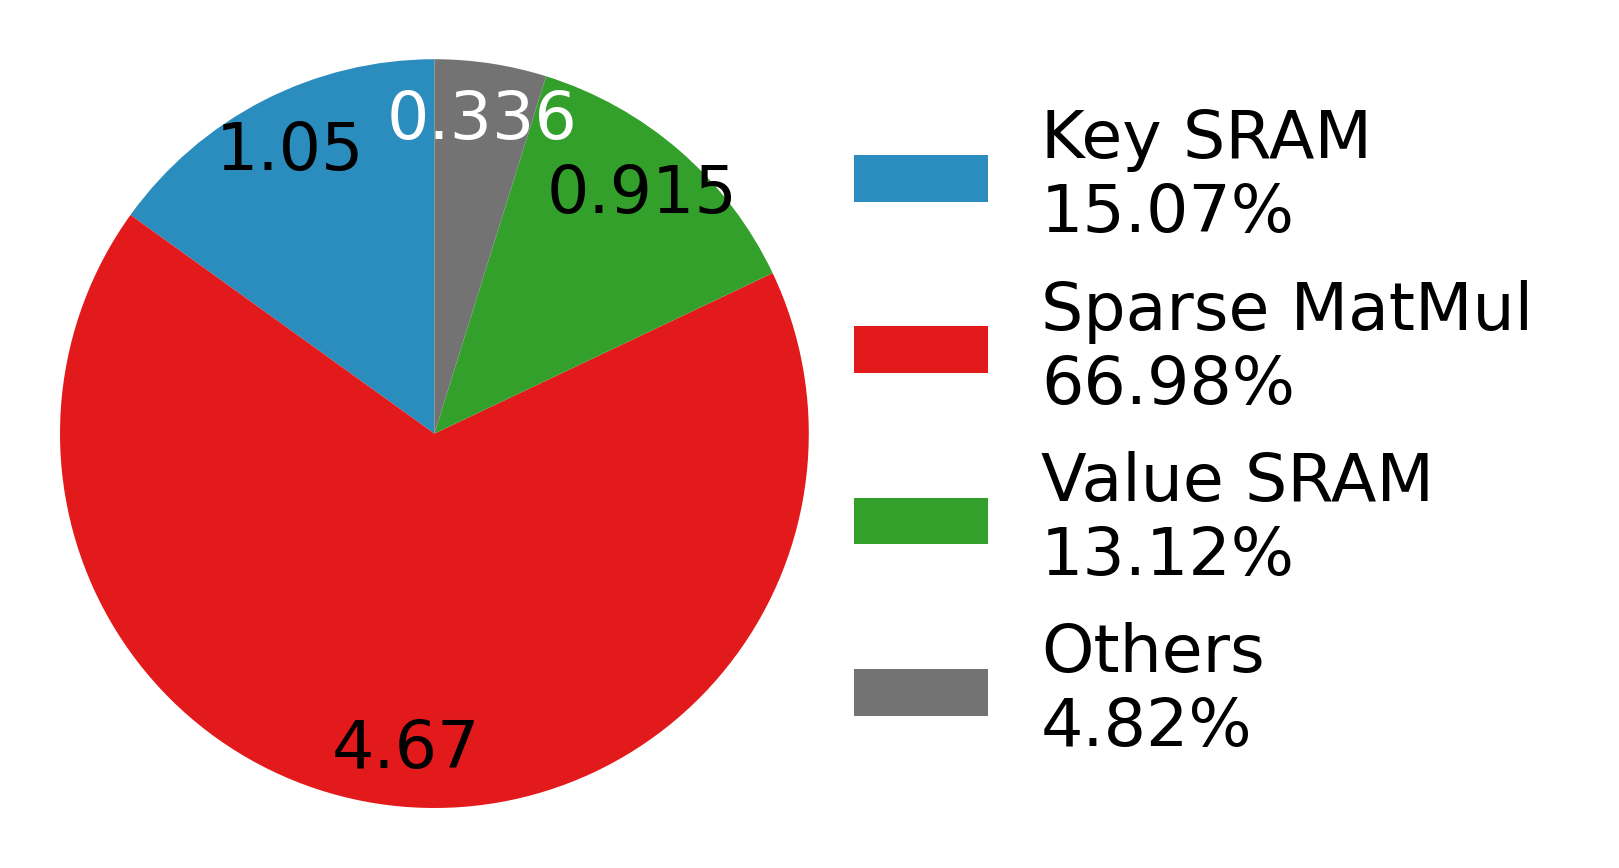

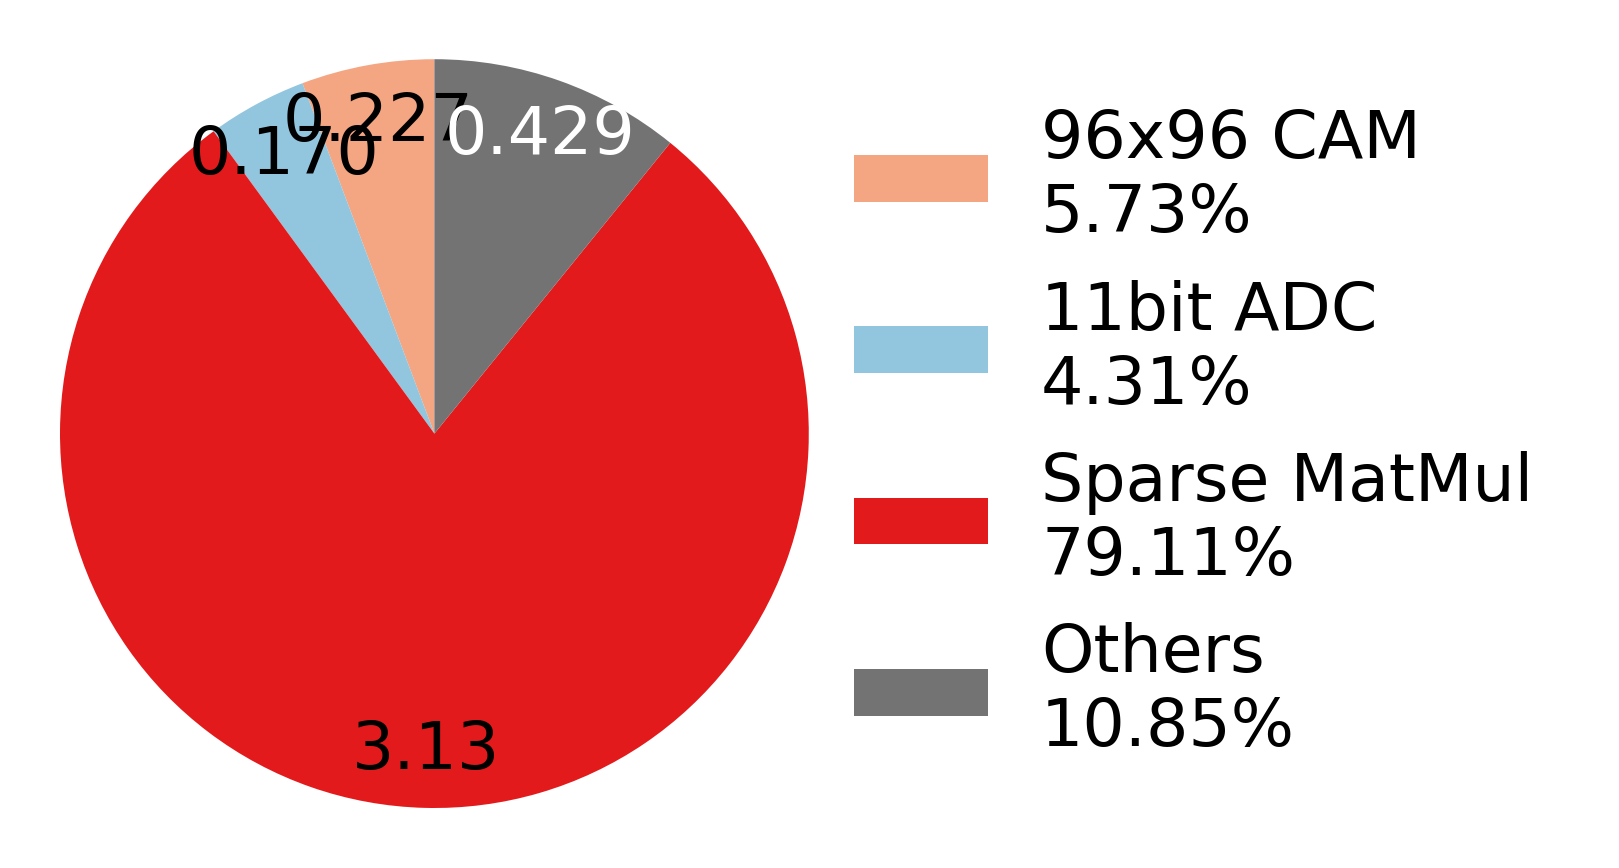

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import rgb_to_hsv, hex2color

# Color mapping dictionary
color_mapping = {
    'Key SRAM': '#2b8cbe',
    'Sparse MatMul': '#e31a1c',
    'Value SRAM': '#33a02c',
    '96x96 CAM': '#f4a582',
    '11bit ADC': '#92c5de',
    'Q buffer': '#7fcdbb',
    'ML_REG': '#41b6c4',
    'CAMH subtractor': '#1d91c0',
    'ACCUM array': '#225ea8',
    'Top3': '#253494',
    'Convert': '#2c7fb8',
    'Top30': '#31a354',
    'SoftMax': '#756bb1',
    'FP32 Accum': '#636363',
    '96x1 buf': '#969696',
    'x8': '#bdbdbd',
    'Others': '#737373'
}

def get_text_color(hex_color):
    """Determine if text should be white or black based on background brightness"""
    rgb = hex2color(hex_color)
    hsv = rgb_to_hsv(rgb)
    # Use value (brightness) from HSV to determine text color
    return 'white' if hsv[2] < 0.6 else 'black'

def process_module_data(input_df, threshold=4, area_col='Area mm2.1', power_col='Power W.1', module_col='Module'):
    input_df = input_df.fillna(0)
    new_labels_area = []
    new_area_values = []
    new_labels_power = []
    new_power_values = []

    area_percentages = input_df[area_col] / input_df[area_col].sum() * 100
    power_percentages = input_df[power_col] / input_df[power_col].sum() * 100

    others_area = 0
    others_power = 0

    for index, row in input_df.iterrows():
        if area_percentages[index] >= threshold:
            new_labels_area.append(row[module_col])
            new_area_values.append(row[area_col])
        else:
            others_area += row[area_col]

        if power_percentages[index] >= threshold:
            new_labels_power.append(row[module_col])
            new_power_values.append(row[power_col])
        else:
            others_power += row[power_col]

    if others_area > 0:
        new_labels_area.append("Others")
        new_area_values.append(others_area)
    if others_power > 0:
        new_labels_power.append("Others")
        new_power_values.append(others_power)

    new_area_percentages = [value/sum(new_area_values)*100 for value in new_area_values]
    new_power_percentages = [value/sum(new_power_values)*100 for value in new_power_values]

    return new_area_values, new_power_values, new_labels_area, new_labels_power, new_area_percentages, new_power_percentages

def create_pie_chart(values, labels, percentages, title, fig_size=(2.5, 1.8)):
    fig, ax = plt.subplots(figsize=fig_size, dpi=600)

    # Map colors to labels using the color dictionary
    colors = [color_mapping[label] for label in labels]

    wedges, texts, autotexts = ax.pie(values,
                                     colors=colors,
                                     autopct='',
                                     startangle=90,
                                     radius=1.3)

    # Add value labels inside pie slices with appropriate text color
    for i, wedge in enumerate(wedges):
        x, y = wedge.center
        angle = np.pi/180 * (wedge.theta1 + wedge.theta2) / 2
        x = x + 1.1 * np.cos(angle)
        y = y + 1.1 * np.sin(angle)
        value_text = f'{values[i]:.2f}' if values[i] >= 1 else f'{values[i]:.3f}'
        text_color = get_text_color(color_mapping[labels[i]])
        ax.text(x, y, value_text, ha='center', va='center', color=text_color, fontsize=8)

    # Create legend
    legend_labels = [f'{labels[i]}\n{percentages[i]:.2f}%' for i in range(len(labels))]
    ax.legend(wedges, legend_labels,
             loc='center left',
             bbox_to_anchor=(1.0, 0.5),
             frameon=False,
             fontsize=8,
             ncol=1)

    plt.tight_layout()
    return fig, ax

# Process data and create charts
area_values, power_values, labels_area, labels_power, area_percentages, power_percentages = process_module_data(df96)

# Create area pie chart
create_pie_chart(area_values, labels_area, area_percentages, '(a) Area')
plt.show()

# Create power pie chart
create_pie_chart(power_values, labels_power, power_percentages, '(b) Power')
plt.show()

In [ ]:
df_titanxp

,model,latency(ms),dynamic power(Watts),energy(Joules)
0,google/vit-base-patch16-224,4.226558,194.949875,0.823967
1,bert-base-cola,14.287604,185.384500,2.648700
2,gpt2-small-1bw,12.681725,181.739200,2.304767
3,gpt2-small-ptb,12.715310,181.573525,2.308764
4,gpt2-small-wikitext103,12.719091,181.524625,2.308828
5,gpt2-small-wikitext2,13.028105,237.909825,3.099514
6,gpt2-medium-1bw,44.575253,177.472750,7.910893
7,gpt2-medium-ptb,44.665835,176.477875,7.882532
8,gpt2-medium-wikitext103,44.660392,176.655675,7.889512
9,gpt2-medium-wikitext2,44.667361,176.465750,7.882259


In [ ]:
df_spatten_speedup

,Model,Over TITAN Xp GPU,Over Xeon CPU,Over Nano GPU,Over Raspberry Pi CPU
0,bert-base-squad-v1,88,165,623,2117
1,bert-base-squad-v2,72,143,524,1526
2,bert-large-squad-v1,68,136,427,2089
3,bert-large-squad-v2,59,108,399,1569
4,bert-base-cola,957,1308,4506,6014
5,bert-base-mnli-mm,159,269,779,2500
6,bert-base-mnli-m,152,255,678,2160
7,bert-base-mrpc,101,206,555,3521
8,bert-base-qnli,148,265,770,4342
9,bert-base-qqp,231,436,1133,2989


# Gateway combination

In [ ]:
# First, let's check for duplicates in each dataframe
print("Checking for duplicate model names:")
print("\nDuplicates in df_model_dims:")
print(df_model_dims['model'][df_finder(sizing_choice = 96, core_num = 2)['model'].duplicated()])
print("\nDuplicates in df_A100:")
print(df_A100['model'][df_A100['model'].duplicated()])
print("\nDuplicates in df_L40:")
print(df_L40['model'][df_L40['model'].duplicated()])
print("\nDuplicates in df_titanxp:")
print(df_titanxp['model'][df_titanxp['model'].duplicated()])

# Create mapping dictionaries instead of using map function
def create_metric_dict(df, model_col, metric_col):
    # If there are duplicates, we'll take the first occurrence
    return df.drop_duplicates(subset=[model_col]).set_index(model_col)[metric_col].to_dict()

# Create mapping dictionaries for each metric
latency_camformer = create_metric_dict(df_model_dims, 'model', 'latency via CAMformer')
power_camformer = create_metric_dict(df_model_dims, 'model', 'power via CAMformer')
energy_camformer = create_metric_dict(df_model_dims, 'model', 'energy via CAMformer')

latency_a100 = create_metric_dict(df_A100_metrics, 'model', 'latency(s)')
power_a100 = create_metric_dict(df_A100_metrics, 'model', 'dynamic power(Watts)')
energy_a100 = create_metric_dict(df_A100_metrics, 'model', 'energy(Joules)')

latency_l40 = create_metric_dict(df_L40_metrics, 'model', 'latency(s)')
power_l40 = create_metric_dict(df_L40_metrics, 'model', 'dynamic power(Watts)')
energy_l40 = create_metric_dict(df_L40_metrics, 'model', 'energy(Joules)')

latency_titanxp = create_metric_dict(df_titanxp_metrics, 'model', 'latency(s)')
power_titanxp = create_metric_dict(df_titanxp_metrics, 'model', 'dynamic power(Watts)')
energy_titanxp = create_metric_dict(df_titanxp_metrics, 'model', 'energy(Joules)')

# Find common models across all dictionaries
common_models = set(latency_camformer.keys()) & set(latency_a100.keys()) & \
                set(latency_l40.keys()) & set(latency_titanxp.keys())

# Create the comparison dataframes
df_all_devices_latency = pd.DataFrame({
    'model': list(common_models),
    'latency via CAMformer': [latency_camformer[model] for model in common_models],
    'A100': [latency_a100[model] for model in common_models],
    'L40': [latency_l40[model] for model in common_models],
    'TITANXp': [latency_titanxp[model] for model in common_models]
})

df_all_devices_power = pd.DataFrame({
    'model': list(common_models),
    'power via CAMformer': [power_camformer[model] for model in common_models],
    'A100': [power_a100[model] for model in common_models],
    'L40': [power_l40[model] for model in common_models],
    'TITANXp': [power_titanxp[model] for model in common_models]
})

df_all_devices_energy = pd.DataFrame({
    'model': list(common_models),
    'energy via CAMformer': [energy_camformer[model] for model in common_models],
    'A100': [energy_a100[model] for model in common_models],
    'L40': [energy_l40[model] for model in common_models],
    'TITANXp': [energy_titanxp[model] for model in common_models]
})

# Sort all dataframes by model name for consistency
df_all_devices_latency = df_all_devices_latency.sort_values('model').reset_index(drop=True)
df_all_devices_power = df_all_devices_power.sort_values('model').reset_index(drop=True)
df_all_devices_energy = df_all_devices_energy.sort_values('model').reset_index(drop=True)

# Display all three dataframes interactively
from IPython.display import display
pd.set_option('display.max_rows', None)  # Show all rows
display(df_all_devices_latency)
display(df_all_devices_power)
display(df_all_devices_energy)

Checking for duplicate model names:

Duplicates in df_model_dims:
Series([], Name: model, dtype: object)

Duplicates in df_A100:
Series([], Name: model, dtype: object)

Duplicates in df_L40:
Series([], Name: model, dtype: object)

Duplicates in df_titanxp:
20                 bert-base-cola
21    google/vit-base-patch16-224
Name: model, dtype: object


,model,latency via CAMformer,A100,L40,TITANXp
0,bert-base-cola,0.027156,0.008553,0.010022,0.014288
1,bert-base-mnli-m,0.027156,0.008554,0.010144,0.014289
2,bert-base-mnli-mm,0.027156,0.008557,0.010059,0.014742
3,bert-base-mrpc,0.027156,0.008559,0.010104,0.014515
4,bert-base-qnli,0.027156,0.008554,0.010028,0.014544
5,bert-base-qqp,0.027156,0.008555,0.010106,0.013991
6,bert-base-rte,0.027156,0.008553,0.010034,0.014577
7,bert-base-squad-v2,0.027156,0.008551,0.010051,0.014346
8,bert-base-sst2,0.027156,0.008553,0.009995,0.014553
9,bert-large-squad-v2,0.054313,0.028445,0.029168,0.041833


,model,power via CAMformer,A100,L40,TITANXp
0,bert-base-cola,7.912795,216.441325,236.330275,185.384500
1,bert-base-mnli-m,7.912795,209.896050,234.213525,241.005700
2,bert-base-mnli-mm,7.912795,208.086325,231.684950,180.844275
3,bert-base-mrpc,7.912795,211.405350,229.284525,179.820675
4,bert-base-qnli,7.912795,204.719125,236.064300,178.507800
5,bert-base-qqp,7.912795,205.393725,234.900625,241.318925
6,bert-base-rte,7.912795,212.748825,231.028650,177.208675
7,bert-base-squad-v2,7.912795,208.158500,237.312525,183.702575
8,bert-base-sst2,7.912795,215.736325,238.952275,177.190100
9,bert-large-squad-v2,7.912795,202.592700,224.000575,180.993100


,model,energy via CAMformer,A100,L40,TITANXp
0,bert-base-cola,0.228977,1.851168,2.368433,2.648700
1,bert-base-mnli-m,0.228977,1.795427,2.375752,3.443814
2,bert-base-mnli-mm,0.228977,1.780569,2.330554,2.665993
3,bert-base-mrpc,0.228977,1.809478,2.316777,2.610014
4,bert-base-qnli,0.228977,1.751184,2.367238,2.596240
5,bert-base-qqp,0.228977,1.757125,2.373824,3.376253
6,bert-base-rte,0.228977,1.819564,2.318057,2.583212
7,bert-base-squad-v2,0.228977,1.780054,2.385142,2.635356
8,bert-base-sst2,0.228977,1.845141,2.388284,2.578678
9,bert-large-squad-v2,0.443860,5.762708,6.533628,7.571560


In [ ]:
# Calculate speedups over each device
df_speedups = pd.DataFrame()
df_speedups['model'] = df_all_devices_latency[~df_all_devices_latency['model'].str.contains('gpt2-small')]['model']

# CAMformer speedup over each device
df_speedups['CAMformer_over_A100'] = df_all_devices_latency['A100'] / df_all_devices_latency['latency via CAMformer']
df_speedups['CAMformer_over_L40'] = df_all_devices_latency['L40'] / df_all_devices_latency['latency via CAMformer']
df_speedups['CAMformer_over_TITANXp'] = df_all_devices_latency['TITANXp'] / df_all_devices_latency['latency via CAMformer']

df_speedups = df_speedups[df_speedups['model'] != "google/vit-base-patch16-224"]


df_speedups

,model,CAMformer_over_A100,CAMformer_over_L40,CAMformer_over_TITANXp
0,bert-base-cola,0.314943,0.369036,0.526121
1,bert-base-mnli-m,0.314985,0.373522,0.526186
2,bert-base-mnli-mm,0.315095,0.370414,0.542851
3,bert-base-mrpc,0.315184,0.372080,0.534478
4,bert-base-qnli,0.314992,0.369265,0.535568
5,bert-base-qqp,0.315023,0.372127,0.515193
6,bert-base-rte,0.314939,0.369475,0.536786
7,bert-base-squad-v2,0.314895,0.370101,0.528263
8,bert-base-sst2,0.314944,0.368045,0.535901
9,bert-large-squad-v2,0.523720,0.537034,0.770229


In [ ]:
# Calculate energy speedups over each device
df_energy_speedups = pd.DataFrame()
df_energy_speedups['model'] = df_all_devices_energy[~df_all_devices_energy['model'].str.contains('gpt2-small')]['model']

df_energy_speedups['CAMformer_over_A100'] = df_all_devices_energy['A100'] / df_all_devices_energy['energy via CAMformer']
df_energy_speedups['CAMformer_over_L40'] = df_all_devices_energy['L40'] / df_all_devices_energy['energy via CAMformer']
df_energy_speedups['CAMformer_over_TITANXp'] = df_all_devices_energy['TITANXp'] / df_all_devices_energy['energy via CAMformer']

df_energy_speedups = df_energy_speedups[df_energy_speedups['model'] != "google/vit-base-patch16-224"]

df_energy_speedups

,model,CAMformer_over_A100,CAMformer_over_L40,CAMformer_over_TITANXp
0,bert-base-cola,8.084532,10.343563,11.567562
1,bert-base-mnli-m,7.841097,10.375527,15.040032
2,bert-base-mnli-mm,7.776208,10.178136,11.643085
3,bert-base-mrpc,7.902461,10.117968,11.398610
4,bert-base-qnli,7.647876,10.338344,11.338456
5,bert-base-qqp,7.673822,10.367107,14.744975
6,bert-base-rte,7.946510,10.123558,11.281559
7,bert-base-squad-v2,7.773959,10.416536,11.509285
8,bert-base-sst2,8.058211,10.430258,11.261758
9,bert-large-squad-v2,12.983161,14.720015,17.058436


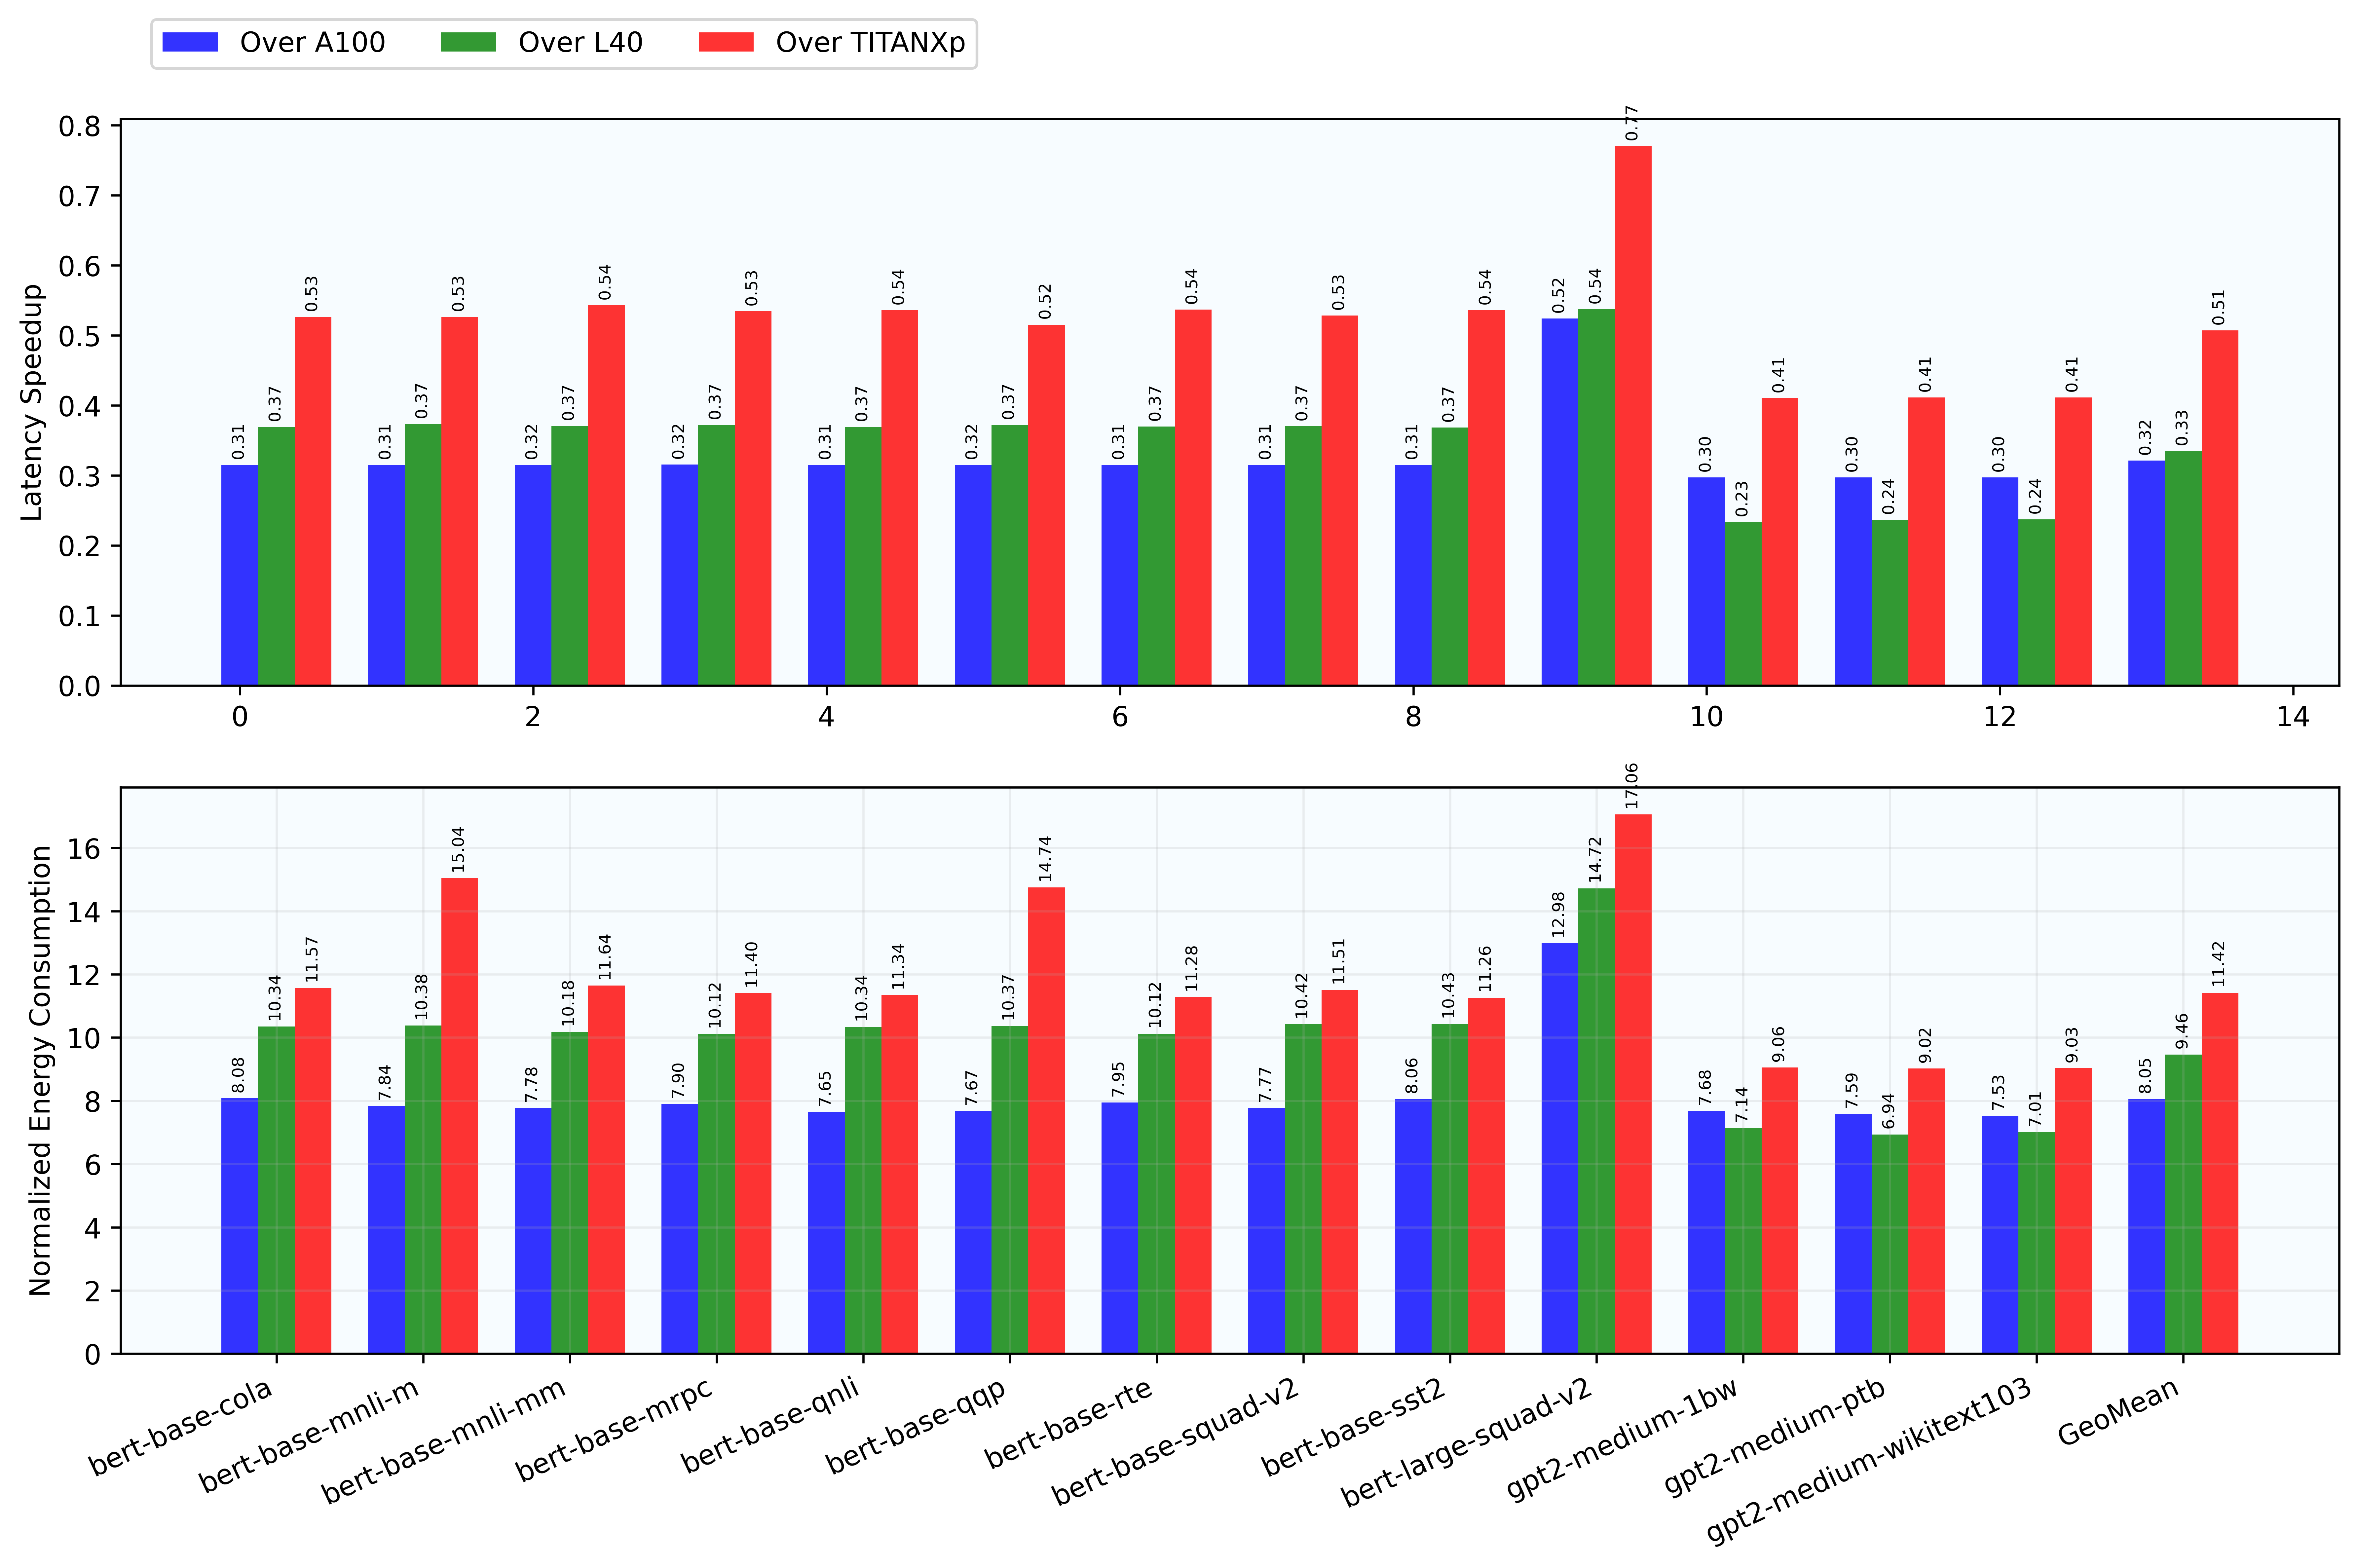

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate geometric mean
def geometric_mean(data):
   return np.exp(np.mean(np.log(data)))

# Add geometric mean to dataframes
for df in [df_speedups, df_energy_speedups]:
   geomean = {
       'model': 'GeoMean',
       'CAMformer_over_A100': geometric_mean(df['CAMformer_over_A100']),
       'CAMformer_over_L40': geometric_mean(df['CAMformer_over_L40']),
       'CAMformer_over_TITANXp': geometric_mean(df['CAMformer_over_TITANXp'])
   }
   df.loc[len(df)] = geomean

blue = "b"
green = "g"
red = "r"

# Plot settings
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), dpi=600)
ax1.set_facecolor('#f7fcff')
ax2.set_facecolor('#f7fcff')
bar_width = 0.25
opacity = 0.8

# Get positions for bars
models = range(len(df_speedups))

# Plot latency speedups
bars1 = ax1.bar(models, df_speedups['CAMformer_over_A100'], bar_width,
       alpha=opacity, color=blue, label='Over A100')
bars2 = ax1.bar([x + bar_width for x in models], df_speedups['CAMformer_over_L40'],
       bar_width, alpha=opacity, color=green, label='Over L40')
bars3 = ax1.bar([x + bar_width*2 for x in models], df_speedups['CAMformer_over_TITANXp'],
       bar_width, alpha=opacity, color=red, label='Over TITANXp')

# Plot energy speedups
bars4 = ax2.bar(models, df_energy_speedups['CAMformer_over_A100'], bar_width,
       alpha=opacity, color=blue)
bars5 = ax2.bar([x + bar_width for x in models], df_energy_speedups['CAMformer_over_L40'],
       bar_width, alpha=opacity, color=green)
bars6 = ax2.bar([x + bar_width*2 for x in models], df_energy_speedups['CAMformer_over_TITANXp'],
       bar_width, alpha=opacity, color=red)

# Add data numbers on top of bars
def add_data_labels(bars, ax):
   for bar in bars:
       height = bar.get_height()
       ax.text(bar.get_x() + bar.get_width() / 2.0, height,
               f' {height:.2f}', ha='center', va='bottom', rotation=90, fontsize = 6)

for bars in [bars1, bars2, bars3]:
   add_data_labels(bars, ax1)

for bars in [bars4, bars5, bars6]:
   add_data_labels(bars, ax2)

# Customize plots
for ax in [ax2]:
   #ax.set_yscale('log')
   ax.set_xticks([x + bar_width for x in models])
   ax.set_xticklabels(df_speedups['model'], rotation=25, ha='right')
   ax.grid(True, which="both", ls="-", alpha=0.2)

# Set title and legend
ax1.set_ylabel('Latency Speedup')
ax2.set_ylabel('Normalized Energy Consumption')
ax1.legend(loc='upper center', bbox_to_anchor=(0.2, 1.20), ncol=3)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate geometric mean
def geometric_mean(data):
   return np.exp(np.mean(np.log(data)))

# Add geometric mean to dataframes
for df in [df_speedups, df_energy_speedups]:
   geomean = {
       'model': 'GeoMean',
       'CAMformer_over_A100': geometric_mean(df['CAMformer_over_A100']),
       'CAMformer_over_L40': geometric_mean(df['CAMformer_over_L40']),
       'CAMformer_over_TITANXp': geometric_mean(df['CAMformer_over_TITANXp'])
   }
   df.loc[len(df)] = geomean



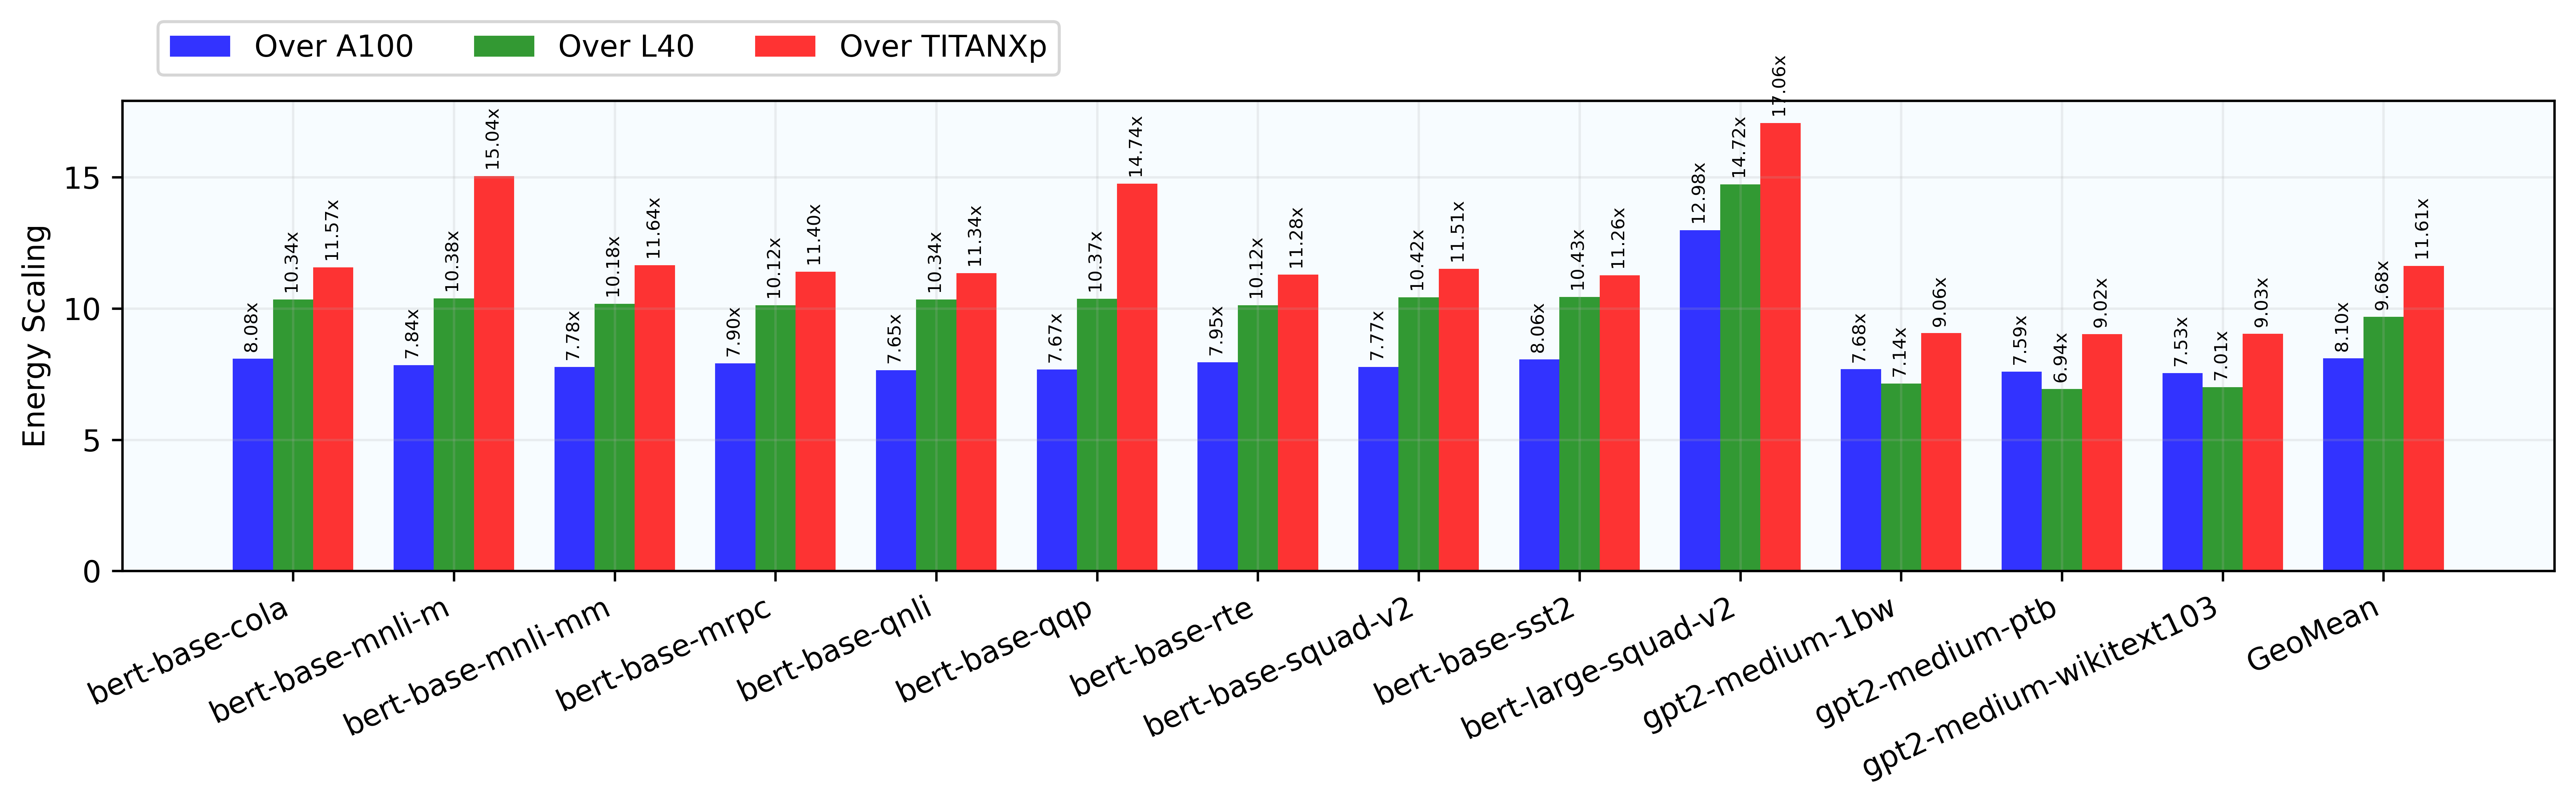

In [ ]:

blue = "b"
green = "g"
red = "r"

# Plot settings
fig, ax2 = plt.subplots(figsize=(12, 4), dpi=600)
ax2.set_facecolor('#f7fcff')
bar_width = 0.25
opacity = 0.8

# Get positions for bars
models = range(len(df_energy_speedups))

# Plot energy speedups
bars4 = ax2.bar(models, df_energy_speedups['CAMformer_over_A100'], bar_width,
       alpha=opacity, color=blue, label='Over A100')
bars5 = ax2.bar([x + bar_width for x in models], df_energy_speedups['CAMformer_over_L40'],
       bar_width, alpha=opacity, color=green, label='Over L40')
bars6 = ax2.bar([x + bar_width*2 for x in models], df_energy_speedups['CAMformer_over_TITANXp'],
       bar_width, alpha=opacity, color=red, label='Over TITANXp')

# Add data numbers on top of bars
def add_data_labels(bars, ax):
   for bar in bars:
       height = bar.get_height()
       ax.text(bar.get_x() + bar.get_width() / 2.0, height,
               f' {height:.2f}x', ha='center', va='bottom', rotation=90, fontsize=6)

for bars in [bars4, bars5, bars6]:
   add_data_labels(bars, ax2)

# Customize plot
#ax2.set_yscale('log')
ax2.set_xticks([x + bar_width for x in models])
ax2.set_xticklabels(df_energy_speedups['model'], rotation=25, ha='right')
ax2.grid(True, which="both", ls="-", alpha=0.2)

# Set title and legend
ax2.set_ylabel('Energy Scaling')
ax2.legend(loc='upper center', bbox_to_anchor=(0.2, 1.2), ncol=3)

plt.tight_layout()
plt.show()

In [ ]:
input_df = df32
input_df = input_df.fillna(0)
area_values = input_df['Area mm2.1'].tolist()  # in mm2
power_values = input_df['Power W.1'].tolist()  # in W
labels = input_df['Module'].tolist()

# Calculate percentages correctly
area_percentages =  (input_df['Area mm2.1'] / input_df['Area mm2.1'].sum()).tolist()     # No need for tolist() here
power_percentages = (input_df['Power W.1'] / input_df['Power W.1'].sum()).tolist()   # No need for tolist() here


print(area_values)
print(power_values)
print(labels)
print(area_percentages)
print(power_percentages)

[0.0123904, 1.051, 0.0127808, 0.0033792, 0.000384, 0.008294400064, 0.002534400064, 0.003878400064, 0.01199480014, 0.001430800004, 0.000468000009, 0.008568000093, 0.01746360018, 4.67, 0.915, 0.0, 0.002913600001, 0.002913600001, 0.000716000016, 0.0]
[0.0232941, 0.0, 0.0240338, 0.0252, 0.0007248, 0.0172928, 0.0075136, 0.0092512, 0.0186348, 0.0007683, 0.0009402, 0.0099705, 0.0249906, 3.13, 0.0, 2e-09, 0.00548, 0.00548, 0.0008784, 0.0]
['Q buffer', 'Key SRAM', 'ML_REG', '32x32 CAM', '32x1 buf', '9bit ADC', 'x8', '-CAMH subtractor', 'ACCUM array', 'Top3', 'Convert', 'Top30', 'SoftMax', 'Sparse MatMul', 'Value SRAM', 'FP32 Accum', 'Out buffer', 'Idx buffer', 'Addr ctrlr', 'DRAM Access']
[0.0018421346066044713, 0.15625673679149174, 0.0019001770709654593, 0.0005024003472557649, 5.709094855179147e-05, 0.0012331644982338538, 0.0003768002699569818, 0.000576618589888252, 0.0017833190564629194, 0.0002127232536881954, 6.957959488556495e-05, 0.0012738418033885611, 0.0025963893213683236, 0.694309192023